In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

cwd = os.getcwd()
root = os.path.dirname(cwd) if cwd.endswith('/code') else cwd

df = pd.read_csv(root + '/artifacts/results_few_models.csv')

traj = (
    df.groupby(['model_id', 'train_tokens_real'], as_index=False)
      .agg(
          val_loss=('val_loss', 'mean'),
          val_loss_std=('val_loss', 'std'),
          mu=('mu_landscape', 'mean'),
          mu_std=('mu_landscape', 'std'),
      )
)
traj['mu'] = np.clip(traj['mu'].to_numpy(), 1e-12, None)
traj['val_loss_std'] = traj['val_loss_std'].fillna(0.0)
traj['mu_std'] = traj['mu_std'].fillna(0.0)
model_ids = sorted(traj['model_id'].unique())

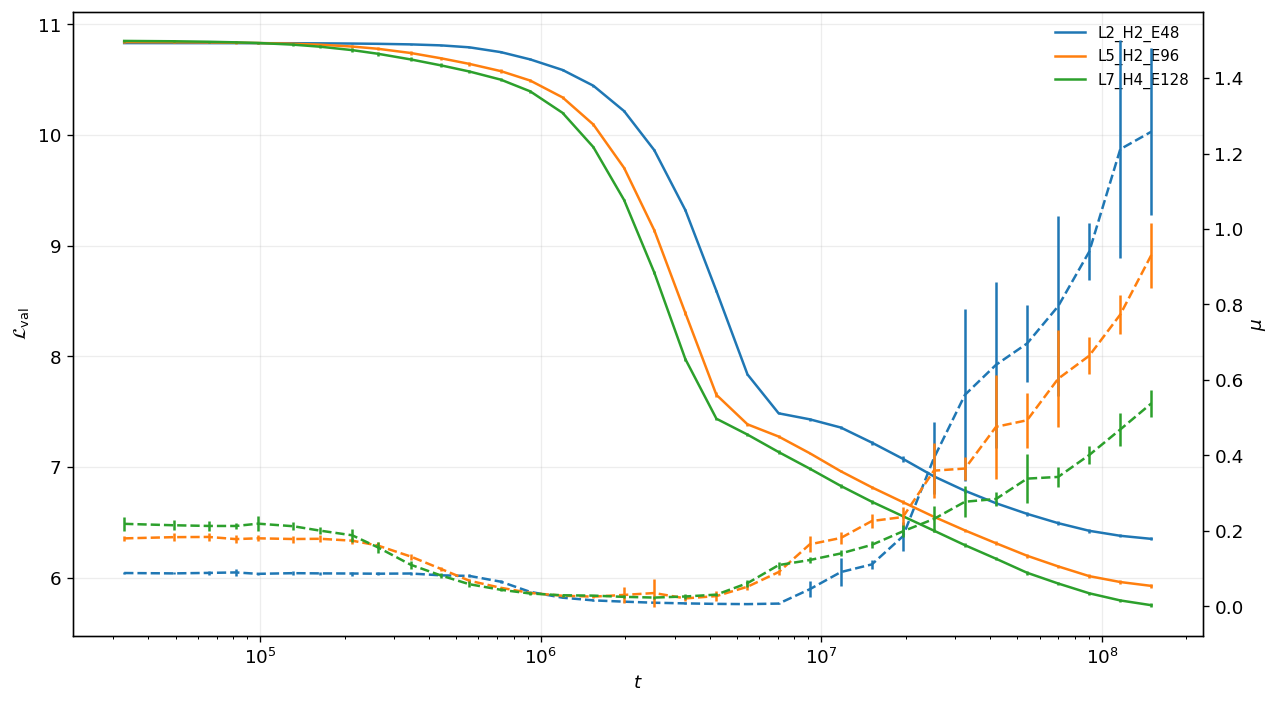

In [2]:
palette = plt.get_cmap('tab10').colors

fig, ax = plt.subplots(figsize=(10.8, 6.0))
for i, model_id in enumerate(model_ids):
    g = traj[traj['model_id'] == model_id].sort_values('train_tokens_real')
    color = palette[i % len(palette)]
    ax.plot(g['train_tokens_real'], g['val_loss'], '-', color=color, label=model_id)
    ax.errorbar(g['train_tokens_real'], g['val_loss'], yerr=g['val_loss_std'], fmt='none', ecolor=color)

ax2 = ax.twinx()
for i, model_id in enumerate(model_ids):
    g = traj[traj['model_id'] == model_id].sort_values('train_tokens_real')
    color = palette[i % len(palette)]
    ax2.plot(g['train_tokens_real'], g['mu'], '--', color=color)
    ax2.errorbar(g['train_tokens_real'], g['mu'], yerr=g['mu_std'], fmt='none', ecolor=color)

ax.set_xscale('log')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\mathcal{L}_{\mathrm{val}}$')
ax2.set_ylabel(r'$\mu$')
ax.grid(True, alpha=0.22)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, frameon=False, fontsize=9, loc='upper right')
fig.tight_layout()

out_path = root + '/paper/figures/fig_few_models_dynamics.png'
fig.savefig(out_path, dpi=300, bbox_inches='tight')

plt.show()

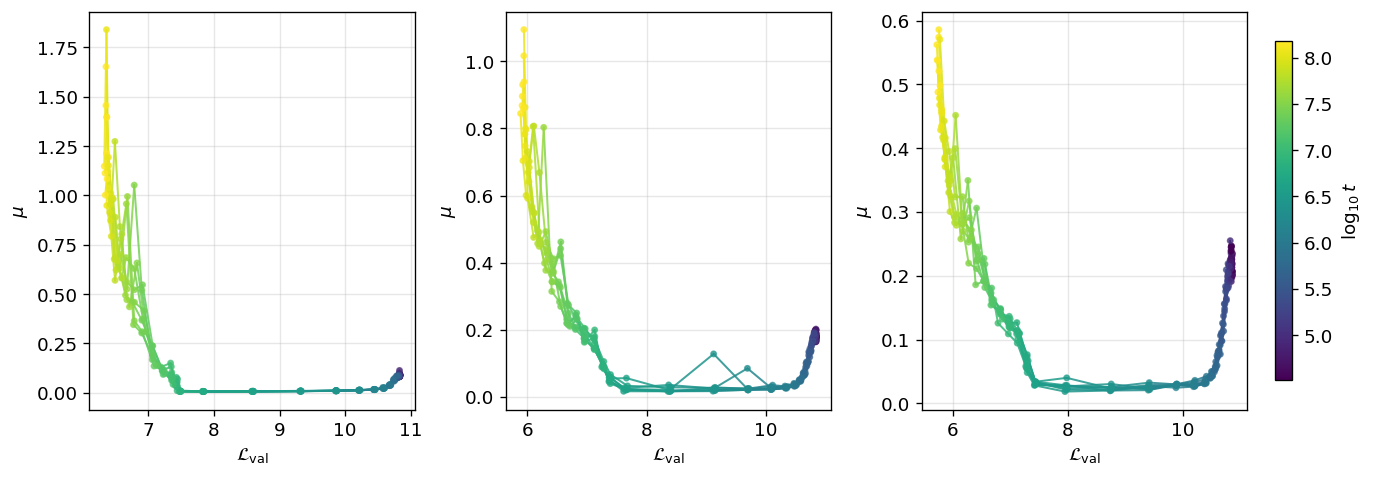

In [3]:
import csv
import math
from collections import defaultdict

os.makedirs(root + '/paper/figures', exist_ok=True)

with open(root + '/artifacts/results_few_models.csv', newline='', encoding='utf-8') as f:
    rows_fm = list(csv.DictReader(f))

by_model_seed = defaultdict(list)
for r in rows_fm:
    key = (r['model_id'], int(r['seed']))
    by_model_seed[key].append(
        (
            float(r['train_tokens_real']),
            float(r['val_loss']),
            float(r['mu_landscape']),
        )
    )
models = sorted({r['model_id'] for r in rows_fm})
all_logt = [math.log10(max(p[0], 1.0)) for pts in by_model_seed.values() for p in pts]
lt_min, lt_max = min(all_logt), max(all_logt)
norm = plt.Normalize(vmin=lt_min, vmax=lt_max)
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4.2), squeeze=False)
cmap = plt.cm.viridis
for ax, mid in zip(axes[0], models):
    for seed in range(8):
        pts = sorted(by_model_seed[(mid, seed)], key=lambda x: x[0])
        if len(pts) < 2:
            continue
        t_arr = np.array([p[0] for p in pts])
        lv = np.array([p[1] for p in pts])
        mu = np.array([p[2] for p in pts])
        logt = np.log10(np.maximum(t_arr, 1.0))
        colors = cmap(norm(logt))
        for i in range(len(pts) - 1):
            ax.plot(
                lv[i : i + 2],
                mu[i : i + 2],
                color=colors[i],
                linewidth=1.2,
                alpha=0.85,
            )
        ax.scatter(lv, mu, c=logt, cmap=cmap, norm=norm, s=10, zorder=4, alpha=0.7)
    ax.set_xlabel(r'$\mathcal{L}_{\mathrm{val}}$')
    ax.set_ylabel(r'$\mu$')
    ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.subplots_adjust(top=0.94, bottom=0.15, wspace=0.28)
cbar = fig.colorbar(sm, ax=axes[0].tolist(), shrink=0.85, pad=0.02)
cbar.set_label(r'$\log_{10} t$')
out_phase = root + '/paper/figures/fig_mu_val_phase_plane.png'
fig.savefig(out_phase, dpi=200, bbox_inches='tight')
plt.show()

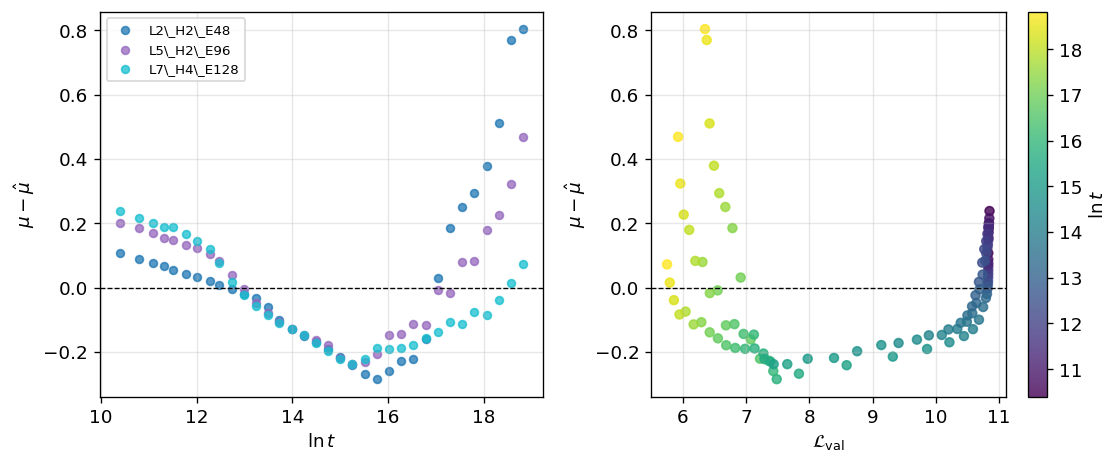

In [4]:
def _ols_r2(X, y):
    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    resid = y - y_hat
    ss_res = float(np.sum(resid**2))
    ss_tot = float(np.sum((y - np.mean(y)) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan')
    return beta, r2


def pearson(a, b):
    a = a - np.mean(a)
    b = b - np.mean(b)
    den = float(np.linalg.norm(a) * np.linalg.norm(b))
    if den <= 0:
        return float('nan')
    return float(np.dot(a, b) / den)


def partial_corr_mu_logt_given_lv(mu_arr, logt_arr, lv_arr):
    r_mt = pearson(mu_arr, logt_arr)
    r_ml = pearson(mu_arr, lv_arr)
    r_tl = pearson(logt_arr, lv_arr)
    den = math.sqrt(max(1e-15, (1 - r_ml * r_ml) * (1 - r_tl * r_tl)))
    return (r_mt - r_ml * r_tl) / den


buckets = defaultdict(lambda: {'lv': [], 'mu': []})
for r in rows_fm:
    key = (r['model_id'], int(r['train_tokens_real']))
    buckets[key]['lv'].append(float(r['val_loss']))
    buckets[key]['mu'].append(float(r['mu_landscape']))
xs_lv = []
xs_logt = []
ys_mu = []
meta_model = []
meta_logt = []
for (mid, tok), d in sorted(buckets.items()):
    lv_m = float(np.mean(d['lv']))
    mu_m = float(np.mean(d['mu']))
    logt = math.log(max(tok, 1.0))
    xs_lv.append(lv_m)
    xs_logt.append(logt)
    ys_mu.append(mu_m)
    meta_model.append(mid)
    meta_logt.append(logt)
lv_arr = np.array(xs_lv)
lt_arr = np.array(xs_logt)
mu_arr = np.array(ys_mu)
X = np.column_stack([np.ones(len(xs_lv)), lv_arr, lt_arr])
beta, r2 = _ols_r2(X, mu_arr)
resid = mu_arr - X @ beta
models_u = sorted(set(meta_model))
per_model_r2 = {}
for m in models_u:
    mask = np.array([x == m for x in meta_model])
    if int(np.sum(mask)) < 4:
        continue
    Xm = X[mask]
    ym = mu_arr[mask]
    _, r2m = _ols_r2(Xm, ym)
    per_model_r2[m] = r2m
pcorr = partial_corr_mu_logt_given_lv(mu_arr, lt_arr, lv_arr)
stats = {
    'beta': beta,
    'r2': r2,
    'lv': lv_arr,
    'logt': lt_arr,
    'mu': mu_arr,
    'resid': resid,
    'model': meta_model,
    'per_model_r2': per_model_r2,
    'partial_corr_mu_lnt_given_lv': pcorr,
}

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
models_u = sorted(set(stats['model']))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(models_u)))
mc = {m: colors[i] for i, m in enumerate(models_u)}
ax = axes[0]
for m in models_u:
    mask = np.array([x == m for x in stats['model']])
    ax.scatter(
        stats['logt'][mask],
        stats['resid'][mask],
        s=22,
        alpha=0.75,
        label=m.replace('_', r'\_'),
        color=mc[m],
    )
ax.axhline(0.0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel(r'$\ln t$')
ax.set_ylabel(r'$\mu - \hat{\mu}$')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='best')
ax = axes[1]
ax.scatter(stats['lv'], stats['resid'], c=stats['logt'], cmap='viridis', s=28, alpha=0.8)
ax.axhline(0.0, color='k', linewidth=0.8, linestyle='--')
ax.set_xlabel(r'$\mathcal{L}_{\mathrm{val}}$')
ax.set_ylabel(r'$\mu - \hat{\mu}$')
plt.colorbar(ax.collections[0], ax=ax, label=r'$\ln t$')
ax.grid(True, alpha=0.3)
fig.tight_layout()
out_res = root + '/paper/figures/fig_mu_residual_vs_loss_time.png'
fig.savefig(out_res, dpi=200, bbox_inches='tight')
plt.show()


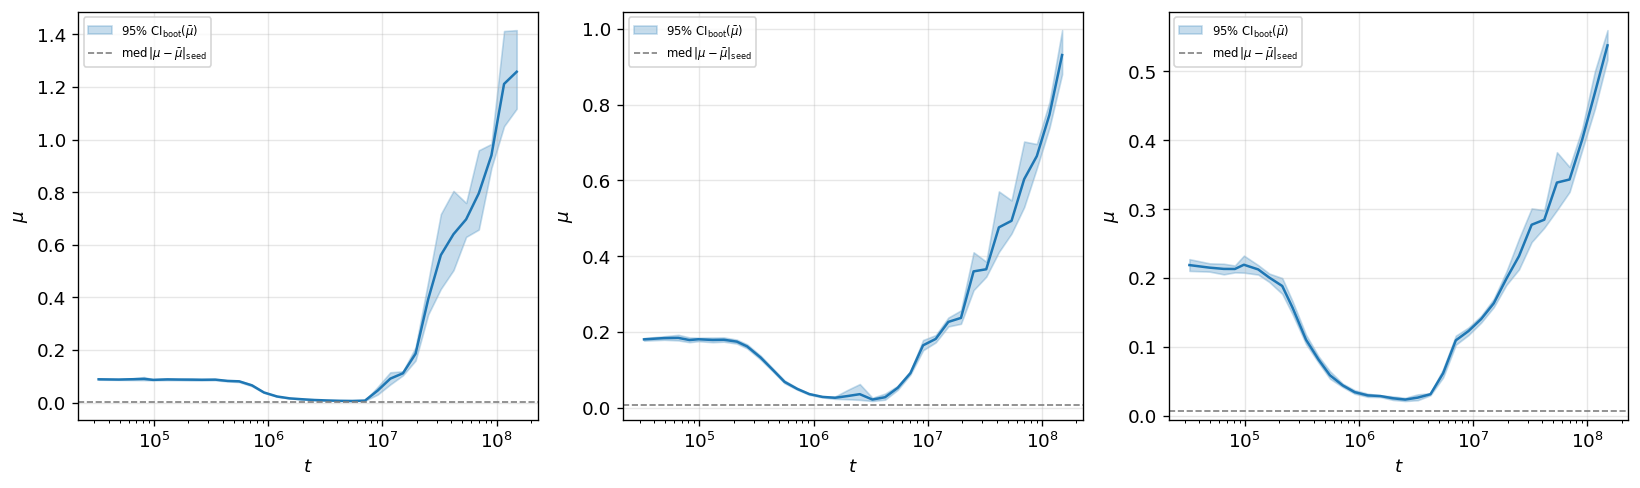

In [5]:
RNG = np.random.default_rng(42)
N_BOOT = 800

_df = pd.read_csv(root + '/artifacts/results_few_models.csv')


def boot_mean_ci(vals):
    vals = np.asarray(vals, dtype=float)
    n = len(vals)
    if n == 0:
        return (float('nan'), float('nan'), float('nan'))
    mu = float(np.mean(vals))
    if n == 1:
        return (mu, mu, mu)
    idx = RNG.integers(0, n, size=(N_BOOT, n))
    boots = np.mean(vals[idx], axis=1)
    return (mu, float(np.quantile(boots, 0.025)), float(np.quantile(boots, 0.975)))

models = sorted(_df['model_id'].unique())
fig, axes = plt.subplots(1, len(models), figsize=(4.6 * len(models), 4.2), squeeze=False)
for ax, mid in zip(axes[0], models):
    sub = _df[_df['model_id'] == mid]
    glist = []
    for tok, g in sub.groupby('train_tokens_real'):
        mu = g['mu_landscape'].to_numpy(float)
        m, lo, hi = boot_mean_ci(mu)
        glist.append((float(tok), m, lo, hi, float(np.median(np.abs(mu - np.mean(mu))))))
    glist.sort(key=lambda x: x[0])
    t_arr = np.array([x[0] for x in glist])
    m_arr = np.array([x[1] for x in glist])
    lo_arr = np.array([x[2] for x in glist])
    hi_arr = np.array([x[3] for x in glist])
    med_abs_dev = np.median([x[4] for x in glist])
    ax.fill_between(t_arr, lo_arr, hi_arr, color='C0', alpha=0.25, label=r'$95\%~\mathrm{CI}_{\mathrm{boot}}(\bar{\mu})$')
    ax.plot(t_arr, m_arr, color='C0', linewidth=1.5)
    ax.axhline(med_abs_dev, color='gray', linestyle='--', linewidth=1.0, label=r'$\mathrm{med}\,|\mu-\bar{\mu}|_{\mathrm{seed}}$')
    ax.set_xscale('log')
    ax.set_xlabel(r'$t$')
    ax.set_ylabel(r'$\mu$')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='best')
fig.tight_layout()
fig.savefig(root + '/paper/figures/fig_mu_seed_dispersion.png', dpi=220, bbox_inches='tight')
plt.show()
